## COVID Drivers: Modeling

This notebook models 
* POST_COVID
* CELL_PHONE
* IMPAIRED_DRIVER
* MATURE_DRIVER
* YOUNG_DRIVER
* FATIGUE_ASLEEP
* HIT_RUN
* UNLICENSED
* URBAN_RURALx</BR></BR>
 ~ AGGRESSIVE_DRIVING

### Table of Contents
* [Read the Data](#read)</BR>
* [Preprocessing](#prep)</BR>
* [Random Forest Classifier](#rfc)</BR>
* [Random Forest Classifier with GridSearchCV](#rf-gs)
* [Logistic Regression with Cross Validation](#lgr-cv)</BR>
* [Logistic Regression with GridSearchCV](#lgr-gs)</BR>
* [XGBoost](#xgb)</BR>
* [XGBoost with GridSearchCV](#xgb-gs)</BR>
* [Review Models](#review)


Import packages

In [78]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import xgboost as xgb
from functools import reduce
#import prince

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [2]:
# Import project specific utilities
from utils.functions import *

In [3]:
path_in = 'data/ready/ready_data.csv'

### <a id='read'>Read the data</a>

In [4]:
df_init = pd.read_csv(path_in, low_memory=False)

In [5]:
df_init['AGGRESSIVE_DRIVING'].sum()/df_init.shape[0]

np.float64(0.5598028680536025)

In [6]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [7]:
df_init.loc[df_init['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')]['AGGRESSIVE_DRIVING'].sum()/df_init.loc[df_init['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')].shape[0]

np.float64(0.5563778090234096)

In [8]:
df = df_init.set_index('CRASH_DATE').drop(columns=['CRN']).copy()

In [9]:
model_metrics = []

In [10]:
df.columns.tolist()

['POST_COVID',
 'ALCOHOL_RELATED',
 'CELL_PHONE',
 'DISTRACTED',
 'DRINKING_DRIVER',
 'DRIVER_16YR',
 'DRIVER_17YR',
 'DRIVER_18YR',
 'DRIVER_19YR',
 'DRIVER_20YR',
 'DRIVER_50_64YR',
 'DRIVER_65_74YR',
 'DRIVER_75PLUS',
 'DRUGGED_DRIVER',
 'DRUG_RELATED',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'ILLEGAL_DRUG_RELATED',
 'IMPAIRED_DRIVER',
 'IMPAIRED_NONMOTORIST',
 'MARIJUANA_DRUGGED_DRIVER',
 'MARIJUANA_RELATED',
 'MATURE_DRIVER',
 'MC_DRINKING_DRIVER',
 'OPIOID_RELATED',
 'UNDERAGE_DRNK_DRV',
 'UNLICENSED',
 'YOUNG_DRIVER',
 'AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING',
 'COUNTYx',
 'URBAN_RURALx']

In [11]:
df['URBAN_RURALx'].unique()

<StringArray>
['Rural', 'Urbanized']
Length: 2, dtype: str

### <a id='prep'>Preprocessing</a>

In [12]:
X = df.loc[:,['POST_COVID',
 'CELL_PHONE',
 'IMPAIRED_DRIVER',
 'MATURE_DRIVER',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'UNLICENSED',
 'URBAN_RURALx']].copy()

In [13]:
y = df['AGGRESSIVE_DRIVING']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [15]:
categorical_cols = ['URBAN_RURALx']

In [16]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ])

### <a id='rfc'>Random Forest Classifier</a>

In [18]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random_forest', RandomForestClassifier(random_state=42))
])

In [19]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains

In [20]:
y_pred = rf_pipeline.predict(X_test)


In [21]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 55.98%


In [22]:
conf_matrix = confusion_matrix(y_test, y_pred)

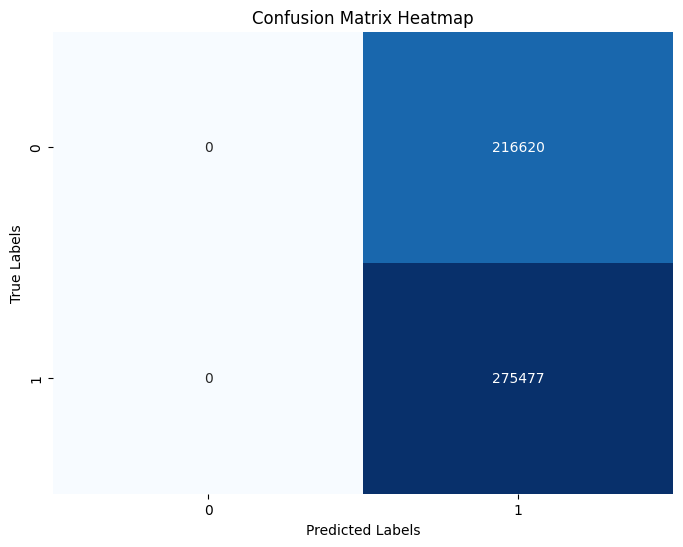

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [24]:
# Predicted probabilities for the class 1
y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]

In [25]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [26]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [27]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [28]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [29]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'RandomForestClassifier'

In [30]:
aggdrv_rf = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [31]:
aggdrv_rf['RandomForestClassifier'] = [round(x, 4) for x in aggdrv_rf['RandomForestClassifier']]

In [32]:
aggdrv_rf

,Measure,RandomForestClassifier
0,Accuracy,0.5598
1,Precision,0.5598
2,Recall,1.0000
3,F1 Score,0.7178
4,ROC AUC,0.5193


In [33]:
model_metrics.append(aggdrv_rf)

In [34]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00    216620
           1       0.56      1.00      0.72    275477

    accuracy                           0.56    492097
   macro avg       0.28      0.50      0.36    492097
weighted avg       0.31      0.56      0.40    492097



/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

### <a id='rf-gs'>Random Forest Classifier with GridSearchCV</a>

In [35]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5],
    'min_samples_split': [2, 5, 8]
}

In [36]:
grid_search = make_pipeline(preprocessor,
                    GridSearchCV(RandomForestClassifier(random_state=42),
                                 param_grid=param_grid,
                                 cv=5,
                                 scoring='f1',
                                 return_train_score=True,
                                 refit=True))

In [37]:
grid_search.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [38]:
y_pred = grid_search.predict(X_test)

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 55.98%


In [40]:
# Predicted probabilities for the class 1
y_pred_proba = grid_search.predict_proba(X_test)[:, 1]

In [41]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [42]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [43]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [44]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [45]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'RandomForestClassifier_GridSearchCV'

In [46]:
aggdrv_rfgs = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [47]:
aggdrv_rfgs['RandomForestClassifier_GridSearchCV'] = [round(x, 4) for x in aggdrv_rfgs['RandomForestClassifier_GridSearchCV']]

In [48]:
aggdrv_rfgs

,Measure,RandomForestClassifier_GridSearchCV
0,Accuracy,0.5598
1,Precision,0.5598
2,Recall,1.0000
3,F1 Score,0.7178
4,ROC AUC,0.5193


In [49]:
model_metrics.append(aggdrv_rfgs)

In [50]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00    216620
           1       0.56      1.00      0.72    275477

    accuracy                           0.56    492097
   macro avg       0.28      0.50      0.36    492097
weighted avg       0.31      0.56      0.40    492097



/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

### <a id='lgr-cv'>Logistic Regression with Cross Validation</a>

In [56]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [57]:
lgr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('logistic_regression', LogisticRegressionCV(random_state=42, cv=skf, solver='saga', l1_ratios=[0.1, 0.25, 0.5, 0.75, 0.9], use_legacy_attributes=False, max_iter=5000))
])

In [58]:
lgr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [59]:
y_pred = lgr_pipeline.predict(X_test)

In [60]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 55.98%


In [61]:
conf_matrix = confusion_matrix(y_test, y_pred)

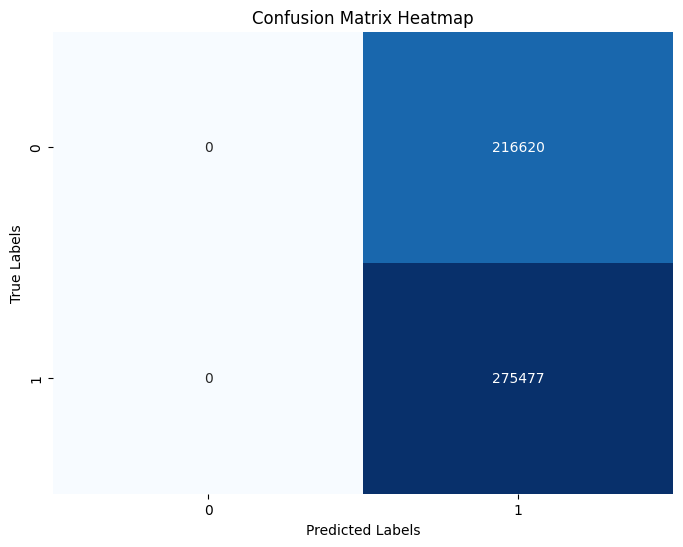

In [62]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [63]:
# Predicted probabilities for the class 1
y_pred_proba = lgr_pipeline.predict_proba(X_test)[:, 1]

In [64]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [65]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [66]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [67]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [68]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'LogisticRegressionCV'

In [69]:
aggdrv_lgr = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [70]:
aggdrv_lgr['LogisticRegressionCV'] = [round(x, 4) for x in aggdrv_lgr['LogisticRegressionCV']]

In [71]:
aggdrv_lgr

,Measure,LogisticRegressionCV
0,Accuracy,0.5598
1,Precision,0.5598
2,Recall,1.0000
3,F1 Score,0.7178
4,ROC AUC,0.5193


In [72]:
model_metrics.append(aggdrv_lgr)

In [73]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00    216620
           1       0.56      1.00      0.72    275477

    accuracy                           0.56    492097
   macro avg       0.28      0.50      0.36    492097
weighted avg       0.31      0.56      0.40    492097



/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

### <a id='lgr-gs'>Logistic Regression with GridSearchCV</a>

In [74]:
np.logspace(-3, 3, 7)

array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])

In [88]:
param_grid = {
    'logistic_regression__C': [0.01, 0.1, 1, 10, 100],
    #'logistic_regression__C': np.logspace(-3, 3, 7),
    'logistic_regression__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
    'logistic_regression__solver': ['saga']
    #'logistic_regression__solver': ['liblinear']
}

In [89]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [90]:
lgr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('logistic_regression', LogisticRegression(random_state=42, max_iter=5000))
])

In [91]:
grid_search = GridSearchCV(
    estimator=lgr_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1,
    error_score='raise'
)

In [92]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logistic_regression__C': [0.01, 0.1, ...], 'logistic_regression__l1_ratio': [0, 0.25, ...], 'logistic_regression__solver': ['saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the

In [93]:
grid_search.best_params_

{'logistic_regression__C': 0.01,
 'logistic_regression__l1_ratio': 0,
 'logistic_regression__solver': 'saga'}

In [94]:
y_pred = grid_search.predict(X_test)

In [95]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 55.98%


In [96]:
conf_matrix = confusion_matrix(y_test, y_pred)

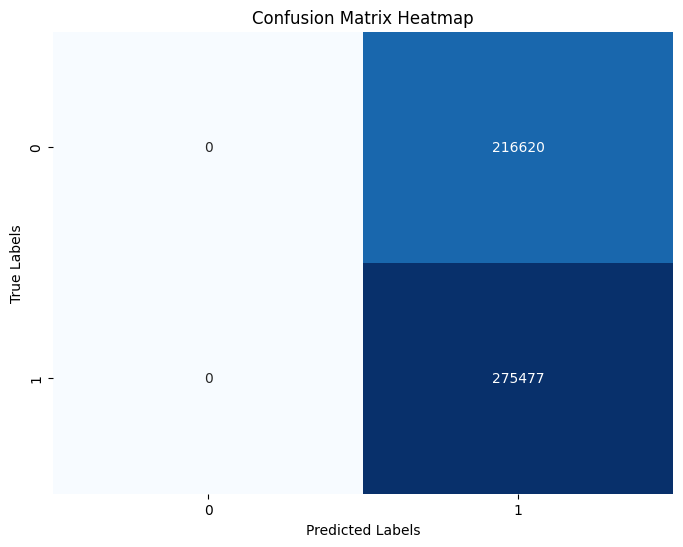

In [97]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [98]:
# Predicted probabilities for the class 1
y_pred_proba = grid_search.predict_proba(X_test)[:, 1]

In [99]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [100]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [101]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [102]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [103]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'LogisticRegression_GridSearchCV'

In [104]:
aggdrv_lgrgs = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [105]:
aggdrv_lgrgs['LogisticRegression_GridSearchCV'] = [round(x, 4) for x in aggdrv_lgrgs['LogisticRegression_GridSearchCV']]

In [106]:
aggdrv_lgrgs

,Measure,LogisticRegression_GridSearchCV
0,Accuracy,0.5598
1,Precision,0.5598
2,Recall,1.0000
3,F1 Score,0.7178
4,ROC AUC,0.5193


In [107]:
model_metrics.append(aggdrv_lgrgs)

In [108]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00    216620
           1       0.56      1.00      0.72    275477

    accuracy                           0.56    492097
   macro avg       0.28      0.50      0.36    492097
weighted avg       0.31      0.56      0.40    492097



/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

### <a id='xgb'>XGBoost</a>

In [109]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgboost', xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        objective='binary:logistic'
     ))
])

In [110]:
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('xgboost', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spars

In [111]:
y_pred = xgb_pipeline.predict(X_test)

In [112]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 55.98%


In [113]:
# Predicted probabilities for the class 1
y_pred_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

In [114]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [115]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [116]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [117]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [118]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'XGBoost'

In [119]:
aggdrv_xgb = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [120]:
aggdrv_xgb['XGBoost'] = [round(x, 4) for x in aggdrv_xgb['XGBoost']]

In [121]:
aggdrv_xgb

,Measure,XGBoost
0,Accuracy,0.5598
1,Precision,0.5598
2,Recall,1.0000
3,F1 Score,0.7178
4,ROC AUC,0.5193


In [122]:
model_metrics.append(aggdrv_xgb)

### <a id='review'>Review Models</a>

In [123]:
merged_metrics = reduce(lambda left, right: pd.merge(left, right, on='Measure', how='inner'), model_metrics)

In [124]:
merged_metrics

,Measure,RandomForestClassifier,RandomForestClassifier_GridSearchCV,LogisticRegressionCV,LogisticRegression_GridSearchCV,XGBoost
0,Accuracy,0.5598,0.5598,0.5598,0.5598,0.5598
1,Precision,0.5598,0.5598,0.5598,0.5598,0.5598
2,Recall,1.0000,1.0000,1.0000,1.0000,1.0000
3,F1 Score,0.7178,0.7178,0.7178,0.7178,0.7178
4,ROC AUC,0.5193,0.5193,0.5193,0.5193,0.5193


In [125]:
merged_metrics.to_csv('data/model_metrics/metrics_09_sec_modl_cofac_aggdrv.csv', index=False)